# 5. Comparación estadística de los modelos

Este capítulo corresponde a la sección 9.10.4.6 del proyecto. Los doce modelos (seis por entorno) se evaluaron sobre **el mismo conjunto de prueba** de 269.062 préstamos. Por eso sus puntuaciones están correlacionadas y deben compararse con pruebas **pareadas**:

| Prueba | Qué compara | Supuestos principales |
|---|---|---|
| **DeLong** (obligatoria) | AUC, es decir, la capacidad de ordenar en todos los umbrales | normalidad asintótica del estimador U de Mann-Whitney |
| **McNemar** | decisiones concretas (aciertos y errores) con un umbral fijo | solo cuentan los pares discordantes |
| **Bootstrap pareado** | ΔAUC, ΔAUC-PR y ΔF1 | ninguna fórmula de varianza; remuestreo de observaciones |

El código de las pruebas está en `lc_stats.py`.

In [1]:
import json
import time
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import average_precision_score, f1_score, roc_auc_score

import lc_stats as S
import lc_utils as U

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 220)
sns.set_theme(style="whitegrid")

sk = pd.read_parquet(U.SCORES_SK).sort_values("id").reset_index(drop=True)
sp = pd.read_parquet(U.SCORES_SPARK).sort_values("id").reset_index(drop=True)
res = {"scikit-learn": json.loads(U.RESULTS_SK.read_text()), "PySpark": json.loads(U.RESULTS_SPARK.read_text())}

assert (sk["id"].to_numpy() == sp["id"].to_numpy()).all() and (sk[U.TARGET].to_numpy() == sp[U.TARGET].to_numpy()).all()
y = sk[U.TARGET].to_numpy()
S_ = {"scikit-learn": sk, "PySpark": sp}
print(f"Observaciones de prueba comunes: {len(y):,} | defaults: {y.sum():,} | mismos id y etiquetas en ambos entornos: True")

Observaciones de prueba comunes: 269,062 | defaults: 53,712 | mismos id y etiquetas en ambos entornos: True


## 5.1 Validación de las implementaciones

**DeLong rápido.** La versión de Sun y Xu (2014) sustituye las $m \cdot n$ comparaciones de la versión original de DeLong et al. (1988) por rangos medios (*midranks*), con complejidad $O(n \log n)$. Con 53.712 defaults y 215.350 no defaults, la versión directa requeriría $1{,}2 \times 10^{10}$ comparaciones por modelo. Antes de usar la versión rápida se valida frente a la directa (`lc_stats.delong_direct`) en submuestras estratificadas de 4000 observaciones, con los doce modelos a la vez: se comparan los AUC y **toda** la matriz de covarianzas $12 \times 12$. No se dispone de R para contrastar con `pROC::roc.test`, así que la referencia es la definición original del estimador.

In [2]:
names = [(env, m) for env in S_ for m in U.MODELS]
score_mat = np.vstack([S_[env][m].to_numpy() for env, m in names])

rng = np.random.default_rng(U.SEED)
val = []
for rep in range(3):
    idx = np.concatenate([rng.choice(np.flatnonzero(y == c), k, replace=False) for c, k in [(0, 3200), (1, 800)]])
    a_f, c_f = S.delong_fast(y[idx], score_mat[:, idx])
    a_d, c_d = S.delong_direct(y[idx], score_mat[:, idx])
    val.append({"submuestra": rep + 1, "máx |ΔAUC|": np.abs(a_f - a_d).max(),
                "máx |Δcov|": np.abs(c_f - c_d).max(), "máx |cov|": np.abs(c_d).max()})
display(pd.DataFrame(val).set_index("submuestra").style.format("{:.2e}"))

t0 = time.time()
auc_all, cov_all = S.delong_fast(y, score_mat)
t_fast = time.time() - t0
auc_sklearn = np.array([roc_auc_score(y, s) for s in score_mat])
print(f"DeLong rápido con los 12 modelos y n = {len(y):,}: {t_fast:.1f} s | "
      f"máx |AUC DeLong − roc_auc_score| = {np.abs(auc_all - auc_sklearn).max():.1e}")

,máx |ΔAUC|,máx |Δcov|,máx |cov|
submuestra,,,
1,1.11e-16,1.36e-20,1.35e-04
2,1.11e-16,1.36e-20,1.28e-04
3,1.11e-16,6.78e-21,1.25e-04


DeLong rápido con los 12 modelos y n = 269,062: 0.9 s | máx |AUC DeLong − roc_auc_score| = 1.1e-16


Las dos versiones coinciden hasta el error de redondeo de punto flotante, en los AUC y en todas las varianzas y covarianzas. El AUC de DeLong coincide además con `roc_auc_score` de scikit-learn en el conjunto de prueba completo.

**Métricas ponderadas del bootstrap.** Cada réplica bootstrap se representa con un vector de pesos $w_i$ (cuántas veces aparece la observación $i$). Así, AUC, AUC-PR y F1 se calculan en $O(n)$ sobre las puntuaciones ordenadas una única vez. Con pesos unitarios deben reproducir `roc_auc_score`, `average_precision_score` y `f1_score` de scikit-learn:

In [3]:
chk = []
for env, m in names:
    s, thr = S_[env][m].to_numpy(), res[env][m]["threshold"]
    a, ap, f1 = S.weighted_metrics(y, s, thr)
    chk.append({"entorno": env, "modelo": m, "|ΔAUC|": abs(a - roc_auc_score(y, s)),
                "|ΔAUC-PR|": abs(ap - average_precision_score(y, s)), "|ΔF1|": abs(f1 - f1_score(y, (s >= thr).astype(int)))})
chk = pd.DataFrame(chk)
print("Máxima diferencia frente a scikit-learn:", chk[["|ΔAUC|", "|ΔAUC-PR|", "|ΔF1|"]].max().map("{:.1e}".format).to_dict())

Máxima diferencia frente a scikit-learn: {'|ΔAUC|': '1.1e-16', '|ΔAUC-PR|': '1.7e-16', '|ΔF1|': '0.0e+00'}


## 5.2 Margen de relevancia práctica

Con 269 mil observaciones, el error estándar del AUC ronda $10^{-3}$, así que diferencias muy pequeñas pueden resultar significativas. **Antes de ver las comparaciones** se fija un margen de relevancia práctica:

$$|\Delta \text{AUC}| \geq 0{,}005$$

La justificación es doble:

* En riesgo de crédito el desempeño se suele expresar como coeficiente de Gini ($= 2\,\text{AUC} - 1$), y 0,005 de AUC equivale a un punto de Gini. Es aproximadamente la mejora mínima que justifica cambiar un modelo de *scoring* en producción.
* 0,005 supera varias veces el error estándar de la diferencia entre modelos. Por eso solo cuentan como relevantes las diferencias claramente distinguibles del ruido de muestreo del conjunto de prueba.

Una diferencia se considera **relevante** si es estadísticamente significativa tras la corrección de Holm **y** $|\Delta\text{AUC}| \geq 0{,}005$.

In [4]:
MARGIN = 0.005
ALPHA = 0.05

def delong_rows(pairs):
    rows = []
    for (e1, m1), (e2, m2) in pairs:
        r = S.delong_test(y, S_[e1][m1].to_numpy(), S_[e2][m2].to_numpy(), alpha=ALPHA)
        rows.append({"modelo 1": f"{m1} ({e1})", "modelo 2": f"{m2} ({e2})", **r})
    df = pd.DataFrame(rows)
    df["p Holm"] = S.holm(df["p"])
    df["significativa"] = df["p Holm"] < ALPHA
    df["relevante"] = df["significativa"] & (df["delta_auc"].abs() >= MARGIN)
    return df

def fmt_delong(df):
    out = pd.DataFrame({
        "modelo 1": df["modelo 1"], "modelo 2": df["modelo 2"],
        "AUC 1 [IC 95 %]": [f"{a:.4f} [{l:.4f}, {h:.4f}]" for a, l, h in df[["auc_1", "auc_1_lo", "auc_1_hi"]].to_numpy()],
        "AUC 2 [IC 95 %]": [f"{a:.4f} [{l:.4f}, {h:.4f}]" for a, l, h in df[["auc_2", "auc_2_lo", "auc_2_hi"]].to_numpy()],
        "ΔAUC [IC 95 %]": [f"{a:+.4f} [{l:+.4f}, {h:+.4f}]" for a, l, h in df[["delta_auc", "delta_lo", "delta_hi"]].to_numpy()],
        "corr.": df["corr"].round(3), "z": df["z"].round(2),
        "p": df["p"].map("{:.2e}".format), "p Holm": df["p Holm"].map("{:.2e}".format),
        "significativa": df["significativa"].map({True: "sí", False: "no"}),
        "relevante (≥ 0,005)": df["relevante"].map({True: "sí", False: "no"}),
    })
    return out

## 5.3 DeLong entre entornos: el mismo modelo en scikit-learn y en PySpark

La primera familia tiene 6 comparaciones y se corrige con Holm dentro de la familia.

In [5]:
between = delong_rows([(("scikit-learn", m), ("PySpark", m)) for m in U.MODELS])
fmt_delong(between)

,modelo 1,modelo 2,AUC 1 [IC 95 %],AUC 2 [IC 95 %],ΔAUC [IC 95 %],corr.,z,p,p Holm,significativa,"relevante (≥ 0,005)"
0,LogReg (scikit-learn),LogReg (PySpark),"0.7135 [0.7111, 0.7158]","0.7135 [0.7111, 0.7158]","-0.0000 [-0.0001, +0.0000]",1.000,-1.19,2.36e-01,3.31e-01,no,no
1,DecisionTree (scikit-learn),DecisionTree (PySpark),"0.7029 [0.7005, 0.7053]","0.7002 [0.6978, 0.7026]","+0.0027 [+0.0017, +0.0037]",0.916,5.31,1.09e-07,3.26e-07,sí,no
2,RandomForest (scikit-learn),RandomForest (PySpark),"0.7151 [0.7127, 0.7174]","0.7137 [0.7114, 0.7161]","+0.0014 [+0.0010, +0.0017]",0.987,6.92,4.51e-12,1.80e-11,sí,no
3,GradBoost (scikit-learn),GradBoost (PySpark),"0.7198 [0.7174, 0.7221]","0.7195 [0.7171, 0.7218]","+0.0003 [-0.0001, +0.0007]",0.985,1.39,1.66e-01,3.31e-01,no,no
4,LinearSVC (scikit-learn),LinearSVC (PySpark),"0.4611 [0.4584, 0.4638]","0.6300 [0.6272, 0.6327]","-0.1688 [-0.1731, -0.1645]",-0.260,-76.81,0.00e+00,0.00e+00,sí,sí
5,NaiveBayes (scikit-learn),NaiveBayes (PySpark),"0.6390 [0.6364, 0.6416]","0.6395 [0.6368, 0.6421]","-0.0005 [-0.0005, -0.0004]",1.000,-12.03,2.34e-33,1.17e-32,sí,no


## 5.4 DeLong entre modelos dentro de cada entorno

En cada entorno hay 15 pares de modelos, que forman dos familias de 15 comparaciones, cada una corregida con Holm. $\Delta\text{AUC} = \text{AUC}_{\text{fila}} - \text{AUC}_{\text{columna}}$.

In [6]:
within = {env: delong_rows([((env, a), (env, b)) for a, b in combinations(U.MODELS, 2)]) for env in S_}
for env, df in within.items():
    print(f"\n=== {env}: {df['significativa'].sum()} de 15 pares significativos | {df['relevante'].sum()} relevantes")
    display(fmt_delong(df))


=== scikit-learn: 15 de 15 pares significativos | 13 relevantes


,modelo 1,modelo 2,AUC 1 [IC 95 %],AUC 2 [IC 95 %],ΔAUC [IC 95 %],corr.,z,p,p Holm,significativa,"relevante (≥ 0,005)"
0,LogReg (scikit-learn),DecisionTree (scikit-learn),"0.7135 [0.7111, 0.7158]","0.7029 [0.7005, 0.7053]","+0.0106 [+0.0094, +0.0118]",0.867,16.90,4.85e-64,1.94e-63,sí,sí
1,LogReg (scikit-learn),RandomForest (scikit-learn),"0.7135 [0.7111, 0.7158]","0.7151 [0.7127, 0.7174]","-0.0016 [-0.0025, -0.0008]",0.935,-3.73,1.94e-04,1.94e-04,sí,no
2,LogReg (scikit-learn),GradBoost (scikit-learn),"0.7135 [0.7111, 0.7158]","0.7198 [0.7174, 0.7221]","-0.0063 [-0.0071, -0.0055]",0.946,-15.99,1.44e-57,4.31e-57,sí,sí
3,LogReg (scikit-learn),LinearSVC (scikit-learn),"0.7135 [0.7111, 0.7158]","0.4611 [0.4584, 0.4638]","+0.2523 [+0.2485, +0.2562]",-0.148,128.49,0.00e+00,0.00e+00,sí,sí
4,LogReg (scikit-learn),NaiveBayes (scikit-learn),"0.7135 [0.7111, 0.7158]","0.6390 [0.6364, 0.6416]","+0.0744 [+0.0722, +0.0767]",0.594,64.65,0.00e+00,0.00e+00,sí,sí
5,DecisionTree (scikit-learn),RandomForest (scikit-learn),"0.7029 [0.7005, 0.7053]","0.7151 [0.7127, 0.7174]","-0.0122 [-0.0132, -0.0112]",0.913,-24.09,3.12e-128,1.56e-127,sí,sí
6,DecisionTree (scikit-learn),GradBoost (scikit-learn),"0.7029 [0.7005, 0.7053]","0.7198 [0.7174, 0.7221]","-0.0169 [-0.0178, -0.0159]",0.919,-34.63,9.37e-263,5.62e-262,sí,sí
7,DecisionTree (scikit-learn),LinearSVC (scikit-learn),"0.7029 [0.7005, 0.7053]","0.4611 [0.4584, 0.4638]","+0.2417 [+0.2379, +0.2455]",-0.110,124.47,0.00e+00,0.00e+00,sí,sí
8,DecisionTree (scikit-learn),NaiveBayes (scikit-learn),"0.7029 [0.7005, 0.7053]","0.6390 [0.6364, 0.6416]","+0.0639 [+0.0612, +0.0665]",0.443,47.18,0.00e+00,0.00e+00,sí,sí
9,RandomForest (scikit-learn),GradBoost (scikit-learn),"0.7151 [0.7127, 0.7174]","0.7198 [0.7174, 0.7221]","-0.0047 [-0.0053, -0.0040]",0.964,-14.45,2.43e-47,4.86e-47,sí,no



=== PySpark: 14 de 15 pares significativos | 14 relevantes


,modelo 1,modelo 2,AUC 1 [IC 95 %],AUC 2 [IC 95 %],ΔAUC [IC 95 %],corr.,z,p,p Holm,significativa,"relevante (≥ 0,005)"
0,LogReg (PySpark),DecisionTree (PySpark),"0.7135 [0.7111, 0.7158]","0.7002 [0.6978, 0.7026]","+0.0133 [+0.0121, +0.0145]",0.869,21.30,1.08e-100,5.39e-100,sí,sí
1,LogReg (PySpark),RandomForest (PySpark),"0.7135 [0.7111, 0.7158]","0.7137 [0.7114, 0.7161]","-0.0002 [-0.0011, +0.0006]",0.935,-0.55,5.81e-01,5.81e-01,no,no
2,LogReg (PySpark),GradBoost (PySpark),"0.7135 [0.7111, 0.7158]","0.7195 [0.7171, 0.7218]","-0.0060 [-0.0068, -0.0052]",0.942,-14.61,2.35e-48,7.06e-48,sí,sí
3,LogReg (PySpark),LinearSVC (PySpark),"0.7135 [0.7111, 0.7158]","0.6300 [0.6272, 0.6327]","+0.0835 [+0.0810, +0.0860]",0.535,66.21,0.00e+00,0.00e+00,sí,sí
4,LogReg (PySpark),NaiveBayes (PySpark),"0.7135 [0.7111, 0.7158]","0.6395 [0.6368, 0.6421]","+0.0740 [+0.0718, +0.0763]",0.589,63.86,0.00e+00,0.00e+00,sí,sí
5,DecisionTree (PySpark),RandomForest (PySpark),"0.7002 [0.6978, 0.7026]","0.7137 [0.7114, 0.7161]","-0.0135 [-0.0145, -0.0126]",0.919,-27.51,1.29e-166,7.75e-166,sí,sí
6,DecisionTree (PySpark),GradBoost (PySpark),"0.7002 [0.6978, 0.7026]","0.7195 [0.7171, 0.7218]","-0.0193 [-0.0202, -0.0183]",0.915,-38.45,0.00e+00,0.00e+00,sí,sí
7,DecisionTree (PySpark),LinearSVC (PySpark),"0.7002 [0.6978, 0.7026]","0.6300 [0.6272, 0.6327]","+0.0702 [+0.0676, +0.0729]",0.476,52.17,0.00e+00,0.00e+00,sí,sí
8,DecisionTree (PySpark),NaiveBayes (PySpark),"0.7002 [0.6978, 0.7026]","0.6395 [0.6368, 0.6421]","+0.0607 [+0.0581, +0.0634]",0.446,44.85,0.00e+00,0.00e+00,sí,sí
9,RandomForest (PySpark),GradBoost (PySpark),"0.7137 [0.7114, 0.7161]","0.7195 [0.7171, 0.7218]","-0.0057 [-0.0065, -0.0050]",0.954,-15.77,4.71e-56,1.88e-55,sí,sí


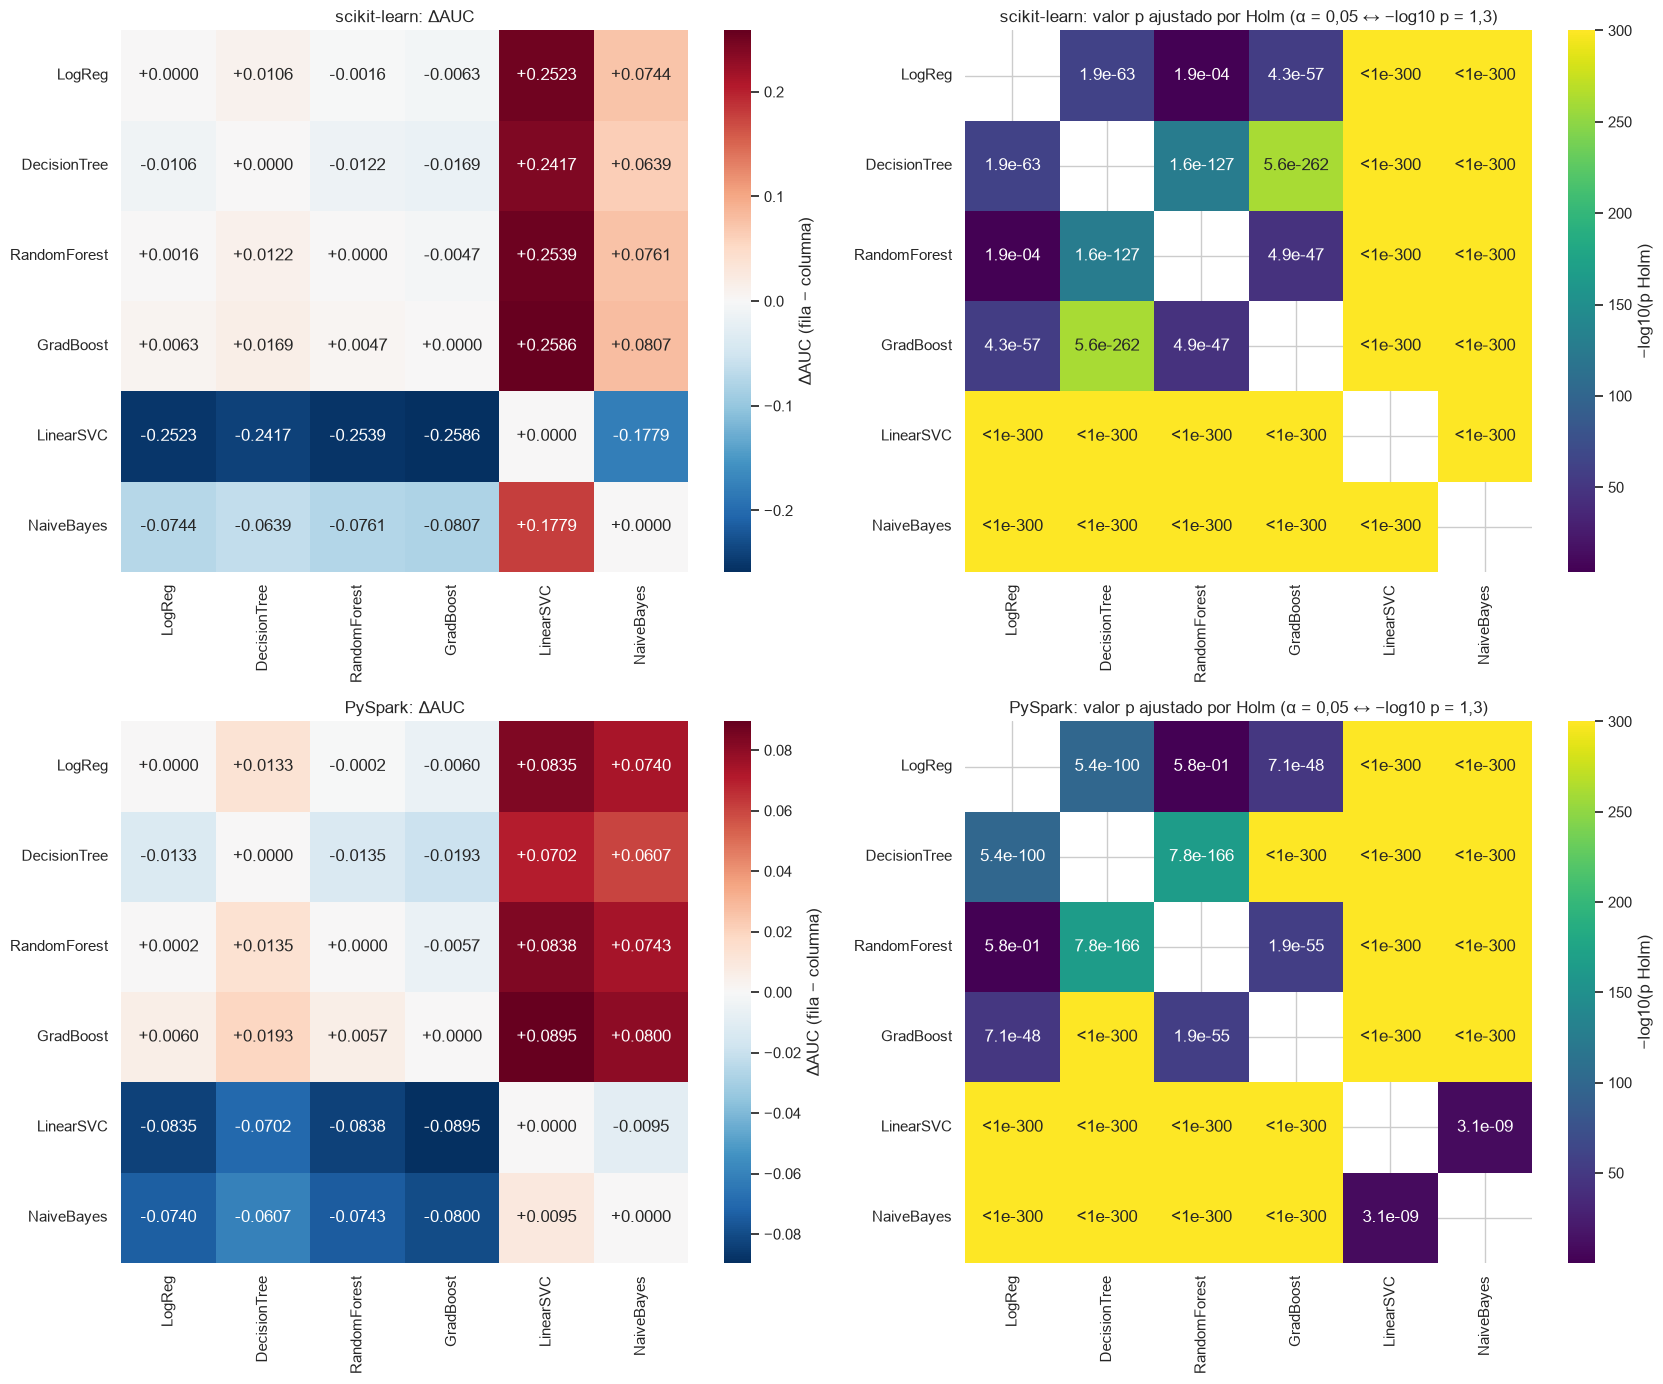

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(17, 14))
for row, (env, df) in enumerate(within.items()):
    d = pd.DataFrame(0.0, index=U.MODELS, columns=U.MODELS)
    p = pd.DataFrame(np.nan, index=U.MODELS, columns=U.MODELS)
    for _, r in df.iterrows():
        a, b = r["modelo 1"].split(" (")[0], r["modelo 2"].split(" (")[0]
        d.loc[a, b], d.loc[b, a] = r["delta_auc"], -r["delta_auc"]
        p.loc[a, b] = p.loc[b, a] = r["p Holm"]
    lim = np.abs(d.to_numpy()).max()
    sns.heatmap(d, annot=True, fmt="+.4f", cmap="RdBu_r", center=0, vmin=-lim, vmax=lim, ax=axes[row, 0],
                cbar_kws={"label": "ΔAUC (fila − columna)"})
    axes[row, 0].set_title(f"{env}: ΔAUC")
    logp = -np.log10(p.clip(lower=1e-300))
    annot = p.map(lambda v: "" if np.isnan(v) else ("<1e-300" if v < 1e-300 else f"{v:.1e}"))
    sns.heatmap(logp, annot=annot, fmt="", cmap="viridis", ax=axes[row, 1], mask=p.isna(),
                cbar_kws={"label": "−log10(p Holm)"})
    axes[row, 1].set_title(f"{env}: valor p ajustado por Holm (α = 0,05 ↔ −log10 p = 1,3)")
plt.tight_layout()
plt.show()

## 5.5 Pruebas complementarias: McNemar y bootstrap pareado

Se aplican a dos familias, cada una corregida con Holm:

* **(i) Entre entornos:** las 6 comparaciones del mismo modelo en scikit-learn y en PySpark.
* **(ii) Mejores modelos:** el par formado por los dos modelos de mayor AUC dentro de cada entorno (2 comparaciones).

**McNemar.** Usa las decisiones con el umbral de cada modelo fijado en el conjunto de entrenamiento (capítulos 3 y 4): el cuantil $1-\pi$ de sus puntuaciones en train. El conjunto de prueba no interviene en esa elección.

**Bootstrap pareado.** Hace $B = 2000$ remuestreos con reemplazo del conjunto de prueba, con semilla 42 y **los mismos índices para ambos modelos**. Se reporta la diferencia observada, el intervalo percentil del 95 % y un valor p bilateral por percentiles, que es el doble de la proporción de réplicas al otro lado de cero, con mínimo $1/B$. Este valor p se corrige con Holm dentro de cada familia y métrica.

In [8]:
top2 = {env: sorted(U.MODELS, key=lambda m: roc_auc_score(y, S_[env][m]), reverse=True)[:2] for env in S_}
families = {
    "(i) entre entornos": [(("scikit-learn", m), ("PySpark", m)) for m in U.MODELS],
    "(ii) dos mejores por entorno": [((env, top2[env][0]), (env, top2[env][1])) for env in S_],
}
print("Dos mejores modelos por AUC:", top2)

B = 2000
comp_rows = []
t0 = time.time()
for fam, pairs in families.items():
    fam_rows = []
    for (e1, m1), (e2, m2) in pairs:
        s1, s2 = S_[e1][m1].to_numpy(), S_[e2][m2].to_numpy()
        t1, t2 = res[e1][m1]["threshold"], res[e2][m2]["threshold"]
        dl = S.delong_test(y, s1, s2)
        mc = S.mcnemar_test(y, (s1 >= t1).astype(int), (s2 >= t2).astype(int))
        bs = S.paired_bootstrap(y, s1, s2, t1, t2, B=B, seed=U.SEED)
        fam_rows.append({"familia": fam, "modelo 1": f"{m1} ({e1})", "modelo 2": f"{m2} ({e2})",
                         "DeLong ΔAUC": dl["delta_auc"], "DeLong p": dl["p"],
                         "McNemar b": mc["b"], "McNemar c": mc["c"], "McNemar χ²": mc["chi2"], "McNemar p": mc["p"],
                         "acc 1": mc["acc_1"], "acc 2": mc["acc_2"],
                         **{f"boot {k} {q}": bs[k][q] for k in ["auc", "pr_auc", "f1"] for q in ["delta", "lo", "hi", "p"]}})
    fam_df = pd.DataFrame(fam_rows)
    for col in ["DeLong p", "McNemar p", "boot auc p", "boot pr_auc p", "boot f1 p"]:
        fam_df[col + " Holm"] = S.holm(fam_df[col])
    comp_rows.append(fam_df)
comp = pd.concat(comp_rows, ignore_index=True)
print(f"McNemar + bootstrap (B = {B}) para {len(comp)} comparaciones: {time.time() - t0:.0f} s")

Dos mejores modelos por AUC: {'scikit-learn': ['GradBoost', 'RandomForest'], 'PySpark': ['GradBoost', 'RandomForest']}


McNemar + bootstrap (B = 2000) para 8 comparaciones: 701 s


In [9]:
mc_tbl = comp[["familia", "modelo 1", "modelo 2", "acc 1", "acc 2", "McNemar b", "McNemar c", "McNemar χ²",
               "McNemar p", "McNemar p Holm"]].copy()
mc_tbl["significativa"] = np.where(mc_tbl["McNemar p Holm"] < ALPHA, "sí", "no")
mc_tbl.style.format({"acc 1": "{:.4f}", "acc 2": "{:.4f}", "McNemar χ²": "{:,.1f}", "McNemar p": "{:.2e}",
                     "McNemar p Holm": "{:.2e}", "McNemar b": "{:,}", "McNemar c": "{:,}"}).hide(axis="index")

familia,modelo 1,modelo 2,acc 1,acc 2,McNemar b,McNemar c,McNemar χ²,McNemar p,McNemar p Holm,significativa
(i) entre entornos,LogReg (scikit-learn),LogReg (PySpark),0.7596,0.7596,253,255,0.0,9.65e-01,1.00e+00,no
(i) entre entornos,DecisionTree (scikit-learn),DecisionTree (PySpark),0.7548,0.7528,"8,614","8,072",17.5,2.81e-05,1.13e-04,sí
(i) entre entornos,RandomForest (scikit-learn),RandomForest (PySpark),0.7605,0.7593,"4,059","3,735",13.4,2.54e-04,7.61e-04,sí
(i) entre entornos,GradBoost (scikit-learn),GradBoost (PySpark),0.7620,0.7618,"5,111","5,054",0.3,5.79e-01,1.00e+00,no
(i) entre entornos,LinearSVC (scikit-learn),LinearSVC (PySpark),0.6674,0.7339,"37,658","55,551","3,434.5",0.00e+00,0.00e+00,sí
(i) entre entornos,NaiveBayes (scikit-learn),NaiveBayes (PySpark),0.7312,0.7319,685,868,21.3,3.87e-06,1.93e-05,sí
(ii) dos mejores por entorno,GradBoost (scikit-learn),RandomForest (scikit-learn),0.7620,0.7605,"7,260","6,852",11.7,6.12e-04,6.12e-04,sí
(ii) dos mejores por entorno,GradBoost (PySpark),RandomForest (PySpark),0.7618,0.7593,"8,601","7,926",27.5,1.58e-07,3.16e-07,sí


In [10]:
bs_tbl = pd.DataFrame({"familia": comp["familia"], "modelo 1": comp["modelo 1"], "modelo 2": comp["modelo 2"]})
for k, lab in [("auc", "ΔAUC"), ("pr_auc", "ΔAUC-PR"), ("f1", "ΔF1")]:
    bs_tbl[f"{lab} [IC 95 %]"] = [f"{d:+.4f} [{l:+.4f}, {h:+.4f}]" for d, l, h in
                                   comp[[f"boot {k} delta", f"boot {k} lo", f"boot {k} hi"]].to_numpy()]
    bs_tbl[f"p Holm {lab}"] = comp[f"boot {k} p Holm"].map("{:.1e}".format)
bs_tbl

,familia,modelo 1,modelo 2,ΔAUC [IC 95 %],p Holm ΔAUC,ΔAUC-PR [IC 95 %],p Holm ΔAUC-PR,ΔF1 [IC 95 %],p Holm ΔF1
0,(i) entre entornos,LogReg (scikit-learn),LogReg (PySpark),"-0.0000 [-0.0001, +0.0000]",2.9e-01,"+0.0001 [+0.0000, +0.0001]",8.8e-02,"-0.0002 [-0.0006, +0.0002]",9.4e-01
1,(i) entre entornos,DecisionTree (scikit-learn),DecisionTree (PySpark),"+0.0027 [+0.0017, +0.0036]",3.0e-03,"+0.0042 [+0.0022, +0.0061]",3.0e-03,"-0.0021 [-0.0043, -0.0000]",1.3e-01
2,(i) entre entornos,RandomForest (scikit-learn),RandomForest (PySpark),"+0.0014 [+0.0010, +0.0017]",3.0e-03,"+0.0019 [+0.0012, +0.0027]",3.0e-03,"+0.0022 [+0.0006, +0.0037]",3.6e-02
3,(i) entre entornos,GradBoost (scikit-learn),GradBoost (PySpark),"+0.0003 [-0.0001, +0.0007]",2.9e-01,"+0.0013 [+0.0004, +0.0023]",9.0e-03,"+0.0006 [-0.0012, +0.0023]",9.4e-01
4,(i) entre entornos,LinearSVC (scikit-learn),LinearSVC (PySpark),"-0.1688 [-0.1732, -0.1645]",3.0e-03,"-0.1179 [-0.1213, -0.1146]",3.0e-03,"-0.1632 [-0.1682, -0.1587]",3.0e-03
5,(i) entre entornos,NaiveBayes (scikit-learn),NaiveBayes (PySpark),"-0.0005 [-0.0005, -0.0004]",3.0e-03,"-0.0004 [-0.0008, +0.0000]",8.8e-02,"-0.0017 [-0.0024, -0.0012]",3.0e-03
6,(ii) dos mejores por entorno,GradBoost (scikit-learn),RandomForest (scikit-learn),"+0.0047 [+0.0041, +0.0053]",1.0e-03,"+0.0077 [+0.0065, +0.0089]",1.0e-03,"+0.0049 [+0.0030, +0.0070]",1.0e-03
7,(ii) dos mejores por entorno,GradBoost (PySpark),RandomForest (PySpark),"+0.0057 [+0.0050, +0.0064]",1.0e-03,"+0.0083 [+0.0069, +0.0096]",1.0e-03,"+0.0065 [+0.0043, +0.0088]",1.0e-03


## 5.6 Síntesis de las tres pruebas

In [11]:
yn = lambda b: "sí" if b else "no"
summary = pd.DataFrame({
    "familia": comp["familia"], "comparación": comp["modelo 1"] + "  vs  " + comp["modelo 2"],
    "ΔAUC": comp["DeLong ΔAUC"].round(4),
    "DeLong (p Holm < 0,05)": [yn(p < ALPHA) for p in comp["DeLong p Holm"]],
    "bootstrap ΔAUC": [yn(p < ALPHA) for p in comp["boot auc p Holm"]],
    "McNemar": [yn(p < ALPHA) for p in comp["McNemar p Holm"]],
    "bootstrap ΔAUC-PR": [yn(p < ALPHA) for p in comp["boot pr_auc p Holm"]],
    "bootstrap ΔF1": [yn(p < ALPHA) for p in comp["boot f1 p Holm"]],
    "relevante (|ΔAUC| ≥ 0,005)": [yn(p < ALPHA and abs(d) >= MARGIN) for p, d in comp[["DeLong p Holm", "DeLong ΔAUC"]].to_numpy()],
})
summary["DeLong = bootstrap AUC"] = np.where(summary["DeLong (p Holm < 0,05)"] == summary["bootstrap ΔAUC"], "✓", "✗")
summary

,familia,comparación,ΔAUC,"DeLong (p Holm < 0,05)",bootstrap ΔAUC,McNemar,bootstrap ΔAUC-PR,bootstrap ΔF1,"relevante (|ΔAUC| ≥ 0,005)",DeLong = bootstrap AUC
0,(i) entre entornos,LogReg (scikit-learn) vs LogReg (PySpark),-0.0000,no,no,no,no,no,no,✓
1,(i) entre entornos,DecisionTree (scikit-learn) vs DecisionTree ...,0.0027,sí,sí,sí,sí,no,no,✓
2,(i) entre entornos,RandomForest (scikit-learn) vs RandomForest ...,0.0014,sí,sí,sí,sí,sí,no,✓
3,(i) entre entornos,GradBoost (scikit-learn) vs GradBoost (PySpark),0.0003,no,no,no,sí,no,no,✓
4,(i) entre entornos,LinearSVC (scikit-learn) vs LinearSVC (PySpark),-0.1688,sí,sí,sí,sí,sí,sí,✓
5,(i) entre entornos,NaiveBayes (scikit-learn) vs NaiveBayes (PyS...,-0.0005,sí,sí,sí,no,sí,no,✓
6,(ii) dos mejores por entorno,GradBoost (scikit-learn) vs RandomForest (sc...,0.0047,sí,sí,sí,sí,sí,no,✓
7,(ii) dos mejores por entorno,GradBoost (PySpark) vs RandomForest (PySpark),0.0057,sí,sí,sí,sí,sí,sí,✓


En esta tabla, "sí" significa diferencia significativa con **valor p ajustado por Holm < 0,05** dentro de su familia, con el mismo criterio para las tres pruebas. Los intervalos percentiles del bootstrap de la sección 5.5 no están corregidos por multiplicidad. Por eso, una diferencia minúscula puede tener un IC que apenas excluye el cero y aun así no ser significativa tras Holm, como el ΔAUC-PR de la regresión logística entre entornos.

## 5.7 Interpretación

En la comparación entre entornos, la regresión logística (ΔAUC < 0,0001; $p_{Holm} = 0{,}33$) y gradient boosting (ΔAUC = +0,0003; $p_{Holm} = 0{,}33$) no presentan diferencias significativas: ambos optimizadores convergen prácticamente a la misma solución. El árbol de decisión (+0,0027), el bosque aleatorio (+0,0014), ambos a favor de scikit-learn, y Naive Bayes (−0,0005) difieren de forma estadísticamente significativa, pero en magnitudes muy inferiores al margen de relevancia de 0,005. En los árboles, la diferencia es coherente con la discretización en `maxBins=32` de Spark frente a los cortes exactos de scikit-learn y con la aleatoriedad del *bootstrap* del bosque. En Naive Bayes, la correlación prácticamente perfecta entre las puntuaciones de ambos entornos reduce tanto el error estándar de la diferencia que hasta 0,0005 resulta significativo; la discrepancia se debe probablemente al pequeño término de estabilidad que scikit-learn suma a las varianzas (`var_smoothing`). La única diferencia a la vez significativa y relevante es la de LinearSVC (ΔAUC = −0,169, a favor de Spark), explicada por el optimizador, como se mostró en la sección 3.6.

Dentro de cada entorno, el orden de los modelos es el mismo: gradient boosting supera al bosque y a la regresión logística, que prácticamente empatan, y estos al árbol, a Naive Bayes y a LinearSVC. En scikit-learn los 15 pares resultan significativos y 13 relevantes; los dos no relevantes son la regresión logística frente al bosque (−0,0016) y el bosque frente a gradient boosting (−0,0047). En PySpark, 14 de los 15 pares son significativos, y la regresión logística y el bosque no se distinguen ($p_{Holm} = 0{,}58$). Gradient boosting supera a la regresión logística por 0,006 en ambos entornos, una diferencia significativa y relevante. Frente al bosque, su ventaja es relevante en PySpark (0,0057) y queda justo por debajo del margen en scikit-learn (0,0047). Que una diferencia de apenas 0,0010 decida la clasificación recuerda que el margen es una convención, cuya frontera no debe sobreinterpretarse. Con 269 mil observaciones y puntuaciones muy correlacionadas entre modelos (entre 0,91 y 0,99 en los modelos de árboles), el error estándar de ΔAUC ronda 0,0002–0,0006. Por eso casi todas las diferencias resultan significativas, y es el margen de relevancia el que permite distinguir las que tienen importancia práctica.

Las tres pruebas son altamente concordantes. DeLong y el bootstrap del AUC coinciden en las ocho comparaciones complementarias, como cabía esperar de dos procedimientos, uno asintótico y otro de remuestreo, que estiman la misma cantidad con una muestra en la que la aproximación normal es excelente. McNemar coincide con DeLong en las ocho comparaciones: no detecta diferencias en la regresión logística ni en gradient boosting entre entornos, y sí en los demás casos. Esto indica que las diferencias de ordenamiento se trasladan a las decisiones con el umbral elegido. Las discrepancias aparecen en las métricas centradas en la clase minoritaria. Entre los dos gradient boosting, el AUC-PR sí difiere (+0,0013; $p_{Holm} = 0{,}009$) aunque el AUC no, porque el AUC-PR pondera sobre todo la región de puntuaciones altas, donde se concentran los defaults, y es más sensible a pequeños cambios en su ordenamiento. En el árbol de decisión, el AUC difiere pero el F1 no ($p_{Holm} = 0{,}13$), porque en un umbral concreto las diferencias de ordenamiento pueden compensarse.

La prueba de DeLong tiene limitaciones relevantes en este diseño. En primer lugar, solo cuantifica la variabilidad debida al muestreo del conjunto de prueba, no la del entrenamiento (semillas, asignación de pliegues, *bootstrap* del bosque o discretización de Spark). Una diferencia de 0,0014 entre dos bosques podría ser comparable a la que produce un simple cambio de semilla, algo que DeLong no puede detectar; hacerlo requeriría repetir el entrenamiento con distintas semillas o particiones, por ejemplo mediante la prueba 5×2cv de Dietterich (1998), inviable aquí por su costo computacional. En segundo lugar, supone observaciones independientes, un supuesto razonable para préstamos distintos, pero que puede debilitarse por dependencias de cohorte, de prestatario o del ciclo económico, que llevarían a subestimar los errores estándar. En tercer lugar, el AUC resume el desempeño en todos los umbrales, de modo que una diferencia de AUC no implica necesariamente una diferencia en el umbral operativo, ni a la inversa, como muestran el F1 del árbol y el AUC-PR del boosting.

Las pruebas complementarias mitigan algunas de estas limitaciones. McNemar evalúa las decisiones en el umbral elegido, aunque trata todos los errores por igual, cuando en riesgo de crédito un falso negativo, es decir, aprobar un préstamo que termina en default, suele ser mucho más costoso que un falso positivo. El bootstrap pareado prescinde de aproximaciones asintóticas y permite comparar el AUC-PR y el F1, las métricas más informativas para la clase minoritaria. Comparte, sin embargo, las dos primeras limitaciones de DeLong, y con 2000 réplicas su valor p mínimo alcanzable es $5 \times 10^{-4}$.

In [12]:
out = {
    "margin": MARGIN,
    "between": between.to_dict(orient="records"),
    "within": {env: df.to_dict(orient="records") for env, df in within.items()},
    "complementary": comp.to_dict(orient="records"),
    "top2": top2,
}
_ = (U.DATA_DIR / "stats_results.json").write_text(json.dumps(out, indent=2, default=float), encoding="utf-8")